In [1]:
import requests
import pandas as pd
from io import StringIO

def fetch_snotel_idaho_inventory():
    url = "https://wcc.sc.egov.usda.gov/nwcc/sntlsites.jsp?state=ID"
    r = requests.get(url, timeout=60)
    r.raise_for_status()

    # IMPORTANT: wrap HTML in a file-like buffer
    html_buf = StringIO(r.text)

    dfs = pd.read_html(html_buf)  # now it cannot be interpreted as a filename
    df = dfs[0].copy()

    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    df["source"] = "SNOTEL_OFFICIAL"
    return df

df_snotel_official = fetch_snotel_idaho_inventory()
print("Official SNOTEL stations in Idaho:", len(df_snotel_official))
df_snotel_official.head()

Official SNOTEL stations in Idaho: 85


,ntwk,state,site_name,ts,start,lat,lon,elev,county,huc,source
0,SNTL,ID,Atlanta Summit (306),NaN,1978-October,43.76,-115.24,7570,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,SNOTEL_OFFICIAL
1,SNTL,ID,Banner Summit (312),NaN,1979-October,44.30,-115.23,7040,Boise,Canyon Creek (170501200202),SNOTEL_OFFICIAL
2,SNTL,ID,Bear Basin (319),NaN,1979-October,44.95,-116.14,5350,Adams,Little Goose Creek-Goose Creek (170602100104),SNOTEL_OFFICIAL
3,SNTL,ID,Bear Canyon (320),NaN,1979-October,43.74,-113.94,7920,Custer,Upper Star Hope Creek (170402180101),SNOTEL_OFFICIAL
4,SNTL,ID,Bear Mountain (323),NaN,1979-October,48.31,-116.07,5460,Bonner,Middle Lightning Creek (170102131202),SNOTEL_OFFICIAL


In [2]:
n_stations = len(df_snotel_official)
print("Official SNOTEL stations in Idaho:", n_stations)

Official SNOTEL stations in Idaho: 85


In [3]:
df_snotel_official["station_id"] = (
    df_snotel_official["site_name"].astype(str).str.extract(r"\((\d+)\)")[0]
)

df_snotel_official["start_year"] = (
    df_snotel_official["start"].astype(str).str.extract(r"(\d{4})")[0].astype(float)
)

current_year = pd.Timestamp.now().year
df_snotel_official["por_years"] = current_year - df_snotel_official["start_year"]

In [4]:
# Example logic if using metloom metadata
key_vars = ["SWE", "SNWD", "TAVG", "PREC"]

# You would compute coverage by checking availability per station

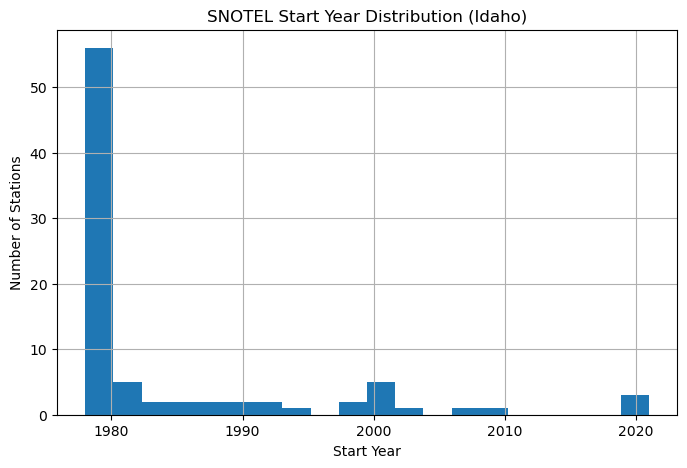

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df_snotel_official["start_year"].hist(bins=20)
plt.xlabel("Start Year")
plt.ylabel("Number of Stations")
plt.title("SNOTEL Start Year Distribution (Idaho)")
plt.show()

In [6]:

df_snotel_official

,ntwk,state,site_name,ts,start,lat,lon,elev,county,huc,source,station_id,start_year,por_years
0,SNTL,ID,Atlanta Summit (306),NaN,1978-October,43.76,-115.24,7570,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,SNOTEL_OFFICIAL,306,1978.0,48.0
1,SNTL,ID,Banner Summit (312),NaN,1979-October,44.30,-115.23,7040,Boise,Canyon Creek (170501200202),SNOTEL_OFFICIAL,312,1979.0,47.0
2,SNTL,ID,Bear Basin (319),NaN,1979-October,44.95,-116.14,5350,Adams,Little Goose Creek-Goose Creek (170602100104),SNOTEL_OFFICIAL,319,1979.0,47.0
3,SNTL,ID,Bear Canyon (320),NaN,1979-October,43.74,-113.94,7920,Custer,Upper Star Hope Creek (170402180101),SNOTEL_OFFICIAL,320,1979.0,47.0
4,SNTL,ID,Bear Mountain (323),NaN,1979-October,48.31,-116.07,5460,Bonner,Middle Lightning Creek (170102131202),SNOTEL_OFFICIAL,323,1979.0,47.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,SNTL,ID,Vienna Mine (845),NaN,1978-October,43.80,-114.85,8930,Blaine,Smiley Creek (170602010201),SNOTEL_OFFICIAL,845,1978.0,48.0
81,SNTL,ID,West Branch (855),NaN,1979-October,45.07,-116.45,5590,Adams,Upper Weiser River (170501240201),SNOTEL_OFFICIAL,855,1979.0,47.0
82,SNTL,ID,White Elephant (860),NaN,1979-October,44.53,-111.41,7670,Fremont,Coffee Pot Creek-Henrys Fork (170402020305),SNOTEL_OFFICIAL,860,1979.0,47.0
83,SNTL,ID,Wildhorse Divide (867),NaN,1979-October,42.76,-112.48,6480,Bannock,Mink Creek (170402080504),SNOTEL_OFFICIAL,867,1979.0,47.0


In [7]:
import re
import pandas as pd

matches = pd.read_csv("out/matches_snotel_synoptic.csv")

# estrai numero stazione
matches["station_id"] = matches["SNOTEL_uid"].str.extract(r"(\d+)").astype(float)

matched_ids = set(matches["station_id"].dropna().astype(int))

print("Unique matched SNOTEL IDs:", len(matched_ids))

Unique matched SNOTEL IDs: 14


In [8]:
import pandas as pd
import numpy as np
import re

df = df_snotel_official.copy()

# Standardize numeric columns
df["lat"]  = pd.to_numeric(df["lat"], errors="coerce")
df["lon"]  = pd.to_numeric(df["lon"], errors="coerce")
df["elev_ft"] = pd.to_numeric(df["elev"], errors="coerce")
df["elev_m"]  = df["elev_ft"] * 0.3048

# Station ID from site_name "Atlanta Summit (306)"
df["station_id"] = df["site_name"].astype(str).str.extract(r"\((\d+)\)")[0]

# Triplet (metloom uses e.g. "306:ID:SNTL")
df["station_triplet"] = df["station_id"].apply(lambda x: f"{x}:ID:SNTL" if pd.notna(x) else pd.NA)

# Parse start year (from "1978-October")
df["start_year"] = pd.to_numeric(df["start"].astype(str).str.extract(r"(\d{4})")[0], errors="coerce")
current_year = pd.Timestamp.utcnow().year
df["por_years_approx"] = current_year - df["start_year"]

# Keep a clean inventory table
cols = ["station_triplet","station_id","site_name","lat","lon","elev_ft","elev_m","county","huc","start","start_year","por_years_approx","source"]
df_station_meta = df[cols].copy()

df_station_meta.to_csv("out/snotel_official_inventory_idaho_clean.csv", index=False)
print("[OUT] out/snotel_official_inventory_idaho_clean.csv", len(df_station_meta))
df_station_meta.head()

[OUT] out/snotel_official_inventory_idaho_clean.csv 85


,station_triplet,station_id,site_name,lat,lon,elev_ft,elev_m,county,huc,start,start_year,por_years_approx,source
0,306:ID:SNTL,306,Atlanta Summit (306),43.76,-115.24,7570,2307.336,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,1978-October,1978,48,SNOTEL_OFFICIAL
1,312:ID:SNTL,312,Banner Summit (312),44.30,-115.23,7040,2145.792,Boise,Canyon Creek (170501200202),1979-October,1979,47,SNOTEL_OFFICIAL
2,319:ID:SNTL,319,Bear Basin (319),44.95,-116.14,5350,1630.680,Adams,Little Goose Creek-Goose Creek (170602100104),1979-October,1979,47,SNOTEL_OFFICIAL
3,320:ID:SNTL,320,Bear Canyon (320),43.74,-113.94,7920,2414.016,Custer,Upper Star Hope Creek (170402180101),1979-October,1979,47,SNOTEL_OFFICIAL
4,323:ID:SNTL,323,Bear Mountain (323),48.31,-116.07,5460,1664.208,Bonner,Middle Lightning Creek (170102131202),1979-October,1979,47,SNOTEL_OFFICIAL


In [9]:
import re
import pandas as pd

matches = pd.read_csv("out/matches_snotel_synoptic.csv")

# estrai numero stazione
matches["station_id"] = matches["SNOTEL_uid"].str.extract(r"(\d+)").astype(float)

matched_ids = set(matches["station_id"].dropna().astype(int))

print("Unique matched SNOTEL IDs:", len(matched_ids))

Unique matched SNOTEL IDs: 14


In [10]:
df_snotel_official["station_id"] = df_snotel_official["station_id"].astype(int)

df_snotel_official["syn_in"] = df_snotel_official["station_id"].isin(matched_ids)

df_snotel_official["syn_out"] = ~df_snotel_official["syn_in"]

In [11]:
df_snotel_official["syn_in"].value_counts()

syn_in
False    71
True     14
Name: count, dtype: int64

In [12]:
df_snotel_official.to_csv(
    "out/snotel_official_inventory_with_synoptic_flag.csv",
    index=False
)

print("[OUT] snotel_official_inventory_with_synoptic_flag.csv")

[OUT] snotel_official_inventory_with_synoptic_flag.csv


In [13]:
df_snotel_official

,ntwk,state,site_name,ts,start,lat,lon,elev,county,huc,source,station_id,start_year,por_years,syn_in,syn_out
0,SNTL,ID,Atlanta Summit (306),NaN,1978-October,43.76,-115.24,7570,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,SNOTEL_OFFICIAL,306,1978.0,48.0,False,True
1,SNTL,ID,Banner Summit (312),NaN,1979-October,44.30,-115.23,7040,Boise,Canyon Creek (170501200202),SNOTEL_OFFICIAL,312,1979.0,47.0,False,True
2,SNTL,ID,Bear Basin (319),NaN,1979-October,44.95,-116.14,5350,Adams,Little Goose Creek-Goose Creek (170602100104),SNOTEL_OFFICIAL,319,1979.0,47.0,False,True
3,SNTL,ID,Bear Canyon (320),NaN,1979-October,43.74,-113.94,7920,Custer,Upper Star Hope Creek (170402180101),SNOTEL_OFFICIAL,320,1979.0,47.0,False,True
4,SNTL,ID,Bear Mountain (323),NaN,1979-October,48.31,-116.07,5460,Bonner,Middle Lightning Creek (170102131202),SNOTEL_OFFICIAL,323,1979.0,47.0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,SNTL,ID,Vienna Mine (845),NaN,1978-October,43.80,-114.85,8930,Blaine,Smiley Creek (170602010201),SNOTEL_OFFICIAL,845,1978.0,48.0,False,True
81,SNTL,ID,West Branch (855),NaN,1979-October,45.07,-116.45,5590,Adams,Upper Weiser River (170501240201),SNOTEL_OFFICIAL,855,1979.0,47.0,False,True
82,SNTL,ID,White Elephant (860),NaN,1979-October,44.53,-111.41,7670,Fremont,Coffee Pot Creek-Henrys Fork (170402020305),SNOTEL_OFFICIAL,860,1979.0,47.0,False,True
83,SNTL,ID,Wildhorse Divide (867),NaN,1979-October,42.76,-112.48,6480,Bannock,Mink Creek (170402080504),SNOTEL_OFFICIAL,867,1979.0,47.0,False,True


In [14]:
from metloom.pointdata.snotel import SnotelPointData

print(type(SnotelPointData.ALLOWED_VARIABLES))
print([v for v in dir(SnotelPointData.ALLOWED_VARIABLES) if v.isupper() and not v.startswith("_")])

<class 'type'>
['PRECIPITATION', 'PRECIPITATIONACCUM', 'RH', 'SNOWDEPTH', 'SOILMOISTURE20IN', 'SOILMOISTURE2IN', 'SOILMOISTURE4IN', 'SOILMOISTURE8IN', 'STREAMVOLUMEADJ', 'STREAMVOLUMEOBS', 'SWE', 'TEMP', 'TEMPAVG', 'TEMPGROUND20IN', 'TEMPGROUND2IN', 'TEMPGROUND4IN', 'TEMPGROUND8IN', 'TEMPMAX', 'TEMPMIN', 'TEMPPROFILE0IN', 'TEMPPROFILE102IN', 'TEMPPROFILE110IN', 'TEMPPROFILE118IN', 'TEMPPROFILE126IN', 'TEMPPROFILE16IN', 'TEMPPROFILE24IN', 'TEMPPROFILE31IN', 'TEMPPROFILE39IN', 'TEMPPROFILE47IN', 'TEMPPROFILE55IN', 'TEMPPROFILE63IN', 'TEMPPROFILE71IN', 'TEMPPROFILE79IN', 'TEMPPROFILE87IN', 'TEMPPROFILE8IN', 'TEMPPROFILE94IN', 'TEMPPROFILENEG8IN']


## Variables description

from datetime import datetime

START = datetime(1980, 1, 1)
END   = datetime(2025, 12, 31)
#START = datetime(1980, 1, 1)SNOTEL Available Variables (Metloom Interface)

The following variables represent the set of meteorological, snow, soil, and hydrological measurements available through the SNOTEL network via the metloom interface. These variables capture surface snowpack dynamics, atmospheric conditions, soil processes, and in some cases streamflow observations.

⸻

❄ Snowpack Variables

SWE

Snow Water Equivalent
The amount of liquid water contained within the snowpack.
Typically measured in inches or millimeters of water equivalent.
This is the primary variable for hydrologic forecasting and water resource assessment.

SNOWDEPTH

Snow Depth
The physical height of the snowpack measured from the ground surface.
Represents snow accumulation but does not account for density variations.

⸻

🌧 Precipitation Variables

PRECIPITATION

Daily incremental precipitation (liquid equivalent).
Represents the amount of precipitation recorded during a given time step.

PRECIPITATIONACCUM

Cumulative precipitation since the beginning of the water year.
Useful for seasonal water balance and accumulation studies.

⸻

🌡 Air Temperature Variables

TEMP

Instantaneous air temperature measurement.

TEMPAVG

Daily average air temperature (reported as “AVG AIR TEMP” in returned data).
Commonly used in snowmelt modeling and degree-day calculations.

TEMPMAX

Daily maximum air temperature.

TEMPMIN

Daily minimum air temperature.

⸻

💧 Atmospheric Moisture

RH

Relative Humidity.
Represents the percentage of moisture in the air relative to saturation.

⸻

🌱 Soil Moisture Variables

These represent volumetric soil water content at different depths (depths in inches):
	•	SOILMOISTURE2IN
	•	SOILMOISTURE4IN
	•	SOILMOISTURE8IN
	•	SOILMOISTURE20IN

These measurements are useful for studying infiltration, soil water storage, and snowmelt–soil interactions.

⸻

🌡 Soil Temperature Variables

Ground temperature measurements at specified depths (in inches):
	•	TEMPGROUND2IN
	•	TEMPGROUND4IN
	•	TEMPGROUND8IN
	•	TEMPGROUND20IN

These are often used in freeze–thaw and soil thermal regime studies.

⸻

🌡 Vertical Temperature Profiles

These represent detailed vertical soil or subsurface temperature measurements at multiple depths:
	•	TEMPPROFILE0IN
	•	TEMPPROFILE8IN
	•	TEMPPROFILE16IN
	•	TEMPPROFILE24IN
	•	TEMPPROFILE31IN
	•	TEMPPROFILE39IN
	•	TEMPPROFILE47IN
	•	TEMPPROFILE55IN
	•	TEMPPROFILE63IN
	•	TEMPPROFILE71IN
	•	TEMPPROFILE79IN
	•	TEMPPROFILE87IN
	•	TEMPPROFILE94IN
	•	TEMPPROFILE102IN
	•	TEMPPROFILE110IN
	•	TEMPPROFILE118IN
	•	TEMPPROFILE126IN
	•	TEMPPROFILENEG8IN

Depths are reported in inches below the ground surface (except NEG8IN, which may represent a sensor above the ground or near-surface air). These profiles support detailed studies of soil thermal gradients, frost depth, and subsurface energy exchange.

⸻

🌊 Streamflow Variables

STREAMVOLUMEOBS

Observed stream volume.
Represents measured streamflow where available.

STREAMVOLUMEADJ

Adjusted stream volume.
Streamflow corrected for calibration or quality-control adjustments.

Not all SNOTEL stations include streamflow measurements.

⸻

Summary

The SNOTEL variable set spans:
	•	Snowpack dynamics (SWE, Snow Depth)
	•	Precipitation accumulation
	•	Atmospheric temperature and humidity
	•	Soil moisture and soil temperature at multiple depths
	•	Detailed subsurface thermal profiles
	•	Streamflow (where instrumented)

For hydrologic and snow-energy studies, the core variables are typically:
	•	SWE
	•	SNOWDEPTH
	•	PRECIPITATIONACCUM
	•	TEMPAVG
	•	TEMPMAX
	•	TEMPMIN

Soil and temperature profile variables are primarily used in advanced snowmelt and land–surface process studies.
#END   = datetime(2025, 12, 31)

import os
import re
import numpy as np
import pandas as pd

# =========================
# 1) Load existing output
# =========================
OUT_CSV = "out/snotel_idaho_variable_metadata_por_gaps.csv"  # <-- quello già prodotto

if not os.path.exists(OUT_CSV):
    raise FileNotFoundError(
        f"Non trovo {OUT_CSV}. Controlla percorso/nome file oppure copialo in out/."
    )

df_snotel_varmeta = pd.read_csv(OUT_CSV)

# parse dates if present
for c in ["por_start", "por_end"]:
    if c in df_snotel_varmeta.columns:
        df_snotel_varmeta[c] = pd.to_datetime(df_snotel_varmeta[c], errors="coerce")

print("[OK] loaded:", OUT_CSV, "rows:", len(df_snotel_varmeta))
df_snotel_varmeta.head()

In [16]:
from datetime import datetime
import numpy as np
import pandas as pd
from metloom.pointdata import SnotelPointData

START = datetime(1980, 1, 1)
END   = datetime(2025, 12, 31)

# elenco variabili come STRINGHE (più semplice per gestire 37 variabili)
VAR_NAMES = [
    "PRECIPITATION", "PRECIPITATIONACCUM", "RH", "SNOWDEPTH",
    "SOILMOISTURE20IN", "SOILMOISTURE2IN", "SOILMOISTURE4IN", "SOILMOISTURE8IN",
    "STREAMVOLUMEADJ", "STREAMVOLUMEOBS", "SWE", "TEMP", "TEMPAVG",
    "TEMPGROUND20IN", "TEMPGROUND2IN", "TEMPGROUND4IN", "TEMPGROUND8IN",
    "TEMPMAX", "TEMPMIN",
    "TEMPPROFILE0IN", "TEMPPROFILE102IN", "TEMPPROFILE110IN", "TEMPPROFILE118IN",
    "TEMPPROFILE126IN", "TEMPPROFILE16IN", "TEMPPROFILE24IN", "TEMPPROFILE31IN",
    "TEMPPROFILE39IN", "TEMPPROFILE47IN", "TEMPPROFILE55IN", "TEMPPROFILE63IN",
    "TEMPPROFILE71IN", "TEMPPROFILE79IN", "TEMPPROFILE87IN", "TEMPPROFILE8IN",
    "TEMPPROFILE94IN", "TEMPPROFILENEG8IN"
]

# enum objects (metloom)
VARS = [getattr(SnotelPointData.ALLOWED_VARIABLES, v) for v in VAR_NAMES]

def gap_stats(ok_mask: np.ndarray):
    missing = (~ok_mask).astype(int)
    gaps, run = [], 0
    for m in missing:
        if m:
            run += 1
        else:
            if run:
                gaps.append(run)
                run = 0
    if run:
        gaps.append(run)
    return {
        "n_gaps": int(len(gaps)),
        "max_gap_days": int(max(gaps)) if gaps else 0,
    }

rows = []  # <<< IMPORTANT

triplets = df_station_meta["station_triplet"].dropna().unique()

for triplet in triplets:
    try:
        s = SnotelPointData(station_id=triplet, name=triplet)
        data = s.get_daily_data(start_date=START, end_date=END, variables=VARS)
    except Exception as e:
        # se fallisce proprio la chiamata, scrivo 1 riga per variabile
        for vname in VAR_NAMES:
            rows.append({
                "station_triplet": triplet,
                "variable": vname,
                "coverage_pct": np.nan,
                "por_start": pd.NaT,
                "por_end": pd.NaT,
                "por_years": np.nan,
                "n_gaps": np.nan,
                "max_gap_days": np.nan,
                "note": "station_fetch_failed",
                "error": str(e),
            })
        continue

    # per ogni variabile richiesta, provo a capire come si chiama la colonna restituita
    returned_cols = set(data.columns)

    for vname in VAR_NAMES:
        # caso speciale: TEMPAVG spesso ritorna come "AVG AIR TEMP"
        candidate_cols = [vname]
        if vname == "TEMPAVG":
            candidate_cols = ["AVG AIR TEMP", "TEMPAVG"]

        col = next((c for c in candidate_cols if c in returned_cols), None)

        if col is None:
            rows.append({
                "station_triplet": triplet,
                "variable": vname,
                "coverage_pct": 0.0,
                "por_start": pd.NaT,
                "por_end": pd.NaT,
                "por_years": np.nan,
                "n_gaps": np.nan,
                "max_gap_days": np.nan,
                "note": "not_returned",
                "error": "",
            })
            continue

        try:
            series = data[col].sort_index()

            valid_idx = series.index[series.notna()]
            if isinstance(valid_idx, pd.MultiIndex):
                valid_times = pd.DatetimeIndex(valid_idx.get_level_values(0))
            else:
                valid_times = pd.DatetimeIndex(valid_idx)

            por_start = valid_times.min() if len(valid_times) else pd.NaT
            por_end   = valid_times.max() if len(valid_times) else pd.NaT
            por_years = (
                (por_end - por_start).days / 365.25
                if pd.notna(por_start) and pd.notna(por_end)
                else np.nan
            )

            ok = series.notna().values
            gs = gap_stats(ok)

            rows.append({
                "station_triplet": triplet,
                "variable": vname,
                "coverage_pct": round(100 * series.notna().mean(), 2),
                "por_start": por_start,
                "por_end": por_end,
                "por_years": round(float(por_years), 3) if np.isfinite(por_years) else np.nan,
                "n_gaps": gs["n_gaps"],
                "max_gap_days": gs["max_gap_days"],
                "note": "",
                "error": "",
            })

        except Exception as e:
            rows.append({
                "station_triplet": triplet,
                "variable": vname,
                "coverage_pct": np.nan,
                "por_start": pd.NaT,
                "por_end": pd.NaT,
                "por_years": np.nan,
                "n_gaps": np.nan,
                "max_gap_days": np.nan,
                "note": "variable_stats_failed",
                "error": str(e),
            })

df_full = pd.DataFrame(rows)
out_csv = "out/snotel_idaho_FULL_variable_metadata_1980_2025.csv"
df_full.to_csv(out_csv, index=False)
print("[OUT]", out_csv, len(df_full))
df_full.head()

No Relative Humidity found for 306:ID:SNTL
No SOIL MOISTURE -4IN found for 306:ID:SNTL
No STREAM VOLUME ADJ found for 306:ID:SNTL
No STREAM VOLUME OBS found for 306:ID:SNTL
No GROUND TEMPERATURE -4IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 0IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 102IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 110IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 118IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 126IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 16IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 24IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 31IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 39IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 47IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 55IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 63IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 71IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 79IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 87IN found for 306:ID:SNTL
No PROFILE TEMPERATURE 8I

[OUT] out/snotel_idaho_FULL_variable_metadata_1980_2025.csv 3145


,station_triplet,variable,coverage_pct,por_start,por_end,por_years,n_gaps,max_gap_days,note,error
0,306:ID:SNTL,PRECIPITATION,97.67,1980-10-01 08:00:00+00:00,2025-12-31 08:00:00+00:00,45.248,2.0,266.0,,
1,306:ID:SNTL,PRECIPITATIONACCUM,0.00,NaT,NaT,NaN,NaN,NaN,not_returned,
2,306:ID:SNTL,RH,0.00,NaT,NaT,NaN,NaN,NaN,not_returned,
3,306:ID:SNTL,SNOWDEPTH,63.56,1996-10-04 08:00:00+00:00,2025-12-31 08:00:00+00:00,29.240,7.0,6113.0,,
4,306:ID:SNTL,SOILMOISTURE20IN,0.00,NaT,NaT,NaN,NaN,NaN,not_returned,


In [ ]:
from datetime import datetime
from metloom.pointdata import SnotelPointData

triplet = "306:ID:SNTL"
s = SnotelPointData(station_id=triplet, name=triplet)

START = datetime(1980,1,1)
END   = datetime(2025,12,31)

data = s.get_daily_data(start_date=START, end_date=END, variables=VARS)

print("Columns returned:")
print(list(data.columns))

In [ ]:
summary = (
    df_full.groupby("variable")
    .agg(
        n_stations=("station_triplet", "nunique"),
        median_coverage=("coverage_pct", "median"),
        p10_coverage=("coverage_pct", lambda x: x.quantile(0.10)),
        p90_coverage=("coverage_pct", lambda x: x.quantile(0.90)),
        median_por=("por_years", "median"),
        p95_max_gap=("max_gap_days", lambda x: x.quantile(0.95)),
    )
    .sort_values("n_stations", ascending=False)
)

summary

In [17]:
df_snotel_varmeta["station_id"] = (
    df_snotel_varmeta["station_triplet"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
)

In [18]:
df_snotel_varmeta = df_snotel_varmeta.merge(
    df_snotel_official[["station_id", "syn_in"]],
    on="station_id",
    how="left"
)

df_snotel_varmeta["syn_in"] = df_snotel_varmeta["syn_in"].fillna(False)

In [19]:
df_snotel_varmeta.groupby(["column_used", "syn_in"])["coverage_pct"].mean()

column_used    syn_in
AVG AIR TEMP   False     99.172535
               True      99.370769
PRECIPITATION  False     99.874507
               True      99.563077
SNOWDEPTH      False     99.786338
               True      99.983077
SWE            False     99.583803
               True      99.991538
Name: coverage_pct, dtype: float64

## Mean  coverage per variable 

In [20]:
df_snotel_varmeta.groupby("column_used")["coverage_pct"].describe()

,count,mean,std,min,25%,50%,75%,max
column_used,,,,,,,,
AVG AIR TEMP,85.0,88.983882,8.041811,78.80,82.05,84.12,98.55,99.94
PRECIPITATION,85.0,99.282118,1.570192,88.47,99.35,99.88,99.99,100.00
SNOWDEPTH,85.0,55.310824,22.729402,18.42,38.99,54.25,63.88,99.99
SWE,85.0,98.975294,2.300428,87.44,98.76,99.97,100.00,100.00


## coverage up to 95%

In [21]:
(df_snotel_varmeta["coverage_pct"] > 95).groupby(
    df_snotel_varmeta["column_used"]
).mean() * 100

column_used
AVG AIR TEMP     36.470588
PRECIPITATION    96.470588
SNOWDEPTH        14.117647
SWE              96.470588
Name: coverage_pct, dtype: float64

## gap severity

In [22]:
df_snotel_varmeta.groupby("column_used")[["n_gaps","max_gap_days"]].median()

,n_gaps,max_gap_days
column_used,,
AVG AIR TEMP,46.0,2457.0
PRECIPITATION,1.0,11.0
SNOWDEPTH,2.0,7133.0
SWE,1.0,1.0


In [23]:
df_snotel_varmeta.groupby("column_used")["max_gap_days"].quantile(0.95)

column_used
AVG AIR TEMP      3164.8
PRECIPITATION      365.0
SNOWDEPTH        12299.8
SWE                365.0
Name: max_gap_days, dtype: float64

In [24]:
df_snotel_varmeta[df_snotel_varmeta["column_used"]=="AVG AIR TEMP"]["max_gap_days"].describe()

count      85.000000
mean     1662.305882
std      1313.413120
min         1.000000
25%        46.000000
50%      2457.000000
75%      2864.000000
max      3234.000000
Name: max_gap_days, dtype: float64

In [25]:
df_snotel_varmeta[
    (df_snotel_varmeta["column_used"]=="AVG AIR TEMP") &
    (df_snotel_varmeta["max_gap_days"] > 30)
][["station_triplet","max_gap_days","coverage_pct"]]

,station_triplet,max_gap_days,coverage_pct
3,306:ID:SNTL,2905,80.87
7,312:ID:SNTL,2722,83.10
11,319:ID:SNTL,2864,82.02
15,320:ID:SNTL,1039,92.49
19,323:ID:SNTL,2772,80.88
...,...,...,...
319,979:ID:SNTL,32,99.45
323,845:ID:SNTL,2678,82.79
327,855:ID:SNTL,2699,82.90
331,860:ID:SNTL,2477,84.36


In [26]:
df_snotel_varmeta[
    (df_snotel_varmeta["column_used"]=="AVG AIR TEMP")
    & (df_snotel_varmeta["max_gap_days"] > 30)
][["station_triplet","syn_in","max_gap_days"]]

,station_triplet,syn_in,max_gap_days
3,306:ID:SNTL,False,2905
7,312:ID:SNTL,False,2722
11,319:ID:SNTL,False,2864
15,320:ID:SNTL,False,1039
19,323:ID:SNTL,False,2772
...,...,...,...
319,979:ID:SNTL,False,32
323,845:ID:SNTL,False,2678
327,855:ID:SNTL,False,2699
331,860:ID:SNTL,False,2477


In [1]:
df_snotel_varmeta.groupby("column_used")["por_years"].describe()

NameError: name 'df_snotel_varmeta' is not defined

In [ ]:
import numpy as np
import pandas as pd

# --- 1) Syn_in flag from matches file ---
matches = pd.read_csv("matches_snotel_synoptic.csv")  # o path completo
# SNOTEL_uid looks like "SNOTEL:537" -> extract numeric id
matches["station_id"] = matches["SNOTEL_uid"].astype(str).str.extract(r"(\d+)")[0].astype(int)
matched_ids = set(matches["station_id"].unique())

# --- 2) Ensure station_id and station_triplet in df_snotel_official ---
official = df_snotel_official.copy()

# if station_id not present, extract from site_name "(306)"
if "station_id" not in official.columns:
    official["station_id"] = official["site_name"].astype(str).str.extract(r"\((\d+)\)")[0].astype(int)

# make triplet
official["station_triplet"] = official["station_id"].astype(str) + ":ID:SNTL"

# syn_in flag
official["syn_in"] = official["station_id"].isin(matched_ids)

# keep only stations with coords
official = official.dropna(subset=["lat", "lon"]).copy()
official["lat"] = official["lat"].astype(float)
official["lon"] = official["lon"].astype(float)

# split
df_in  = official[official["syn_in"]].copy()
df_out = official[~official["syn_in"]].copy()

print("syn_in:", len(df_in), "syn_out:", len(df_out))


# --- 3) Haversine distance (km) between all IN x OUT pairs ---
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2*R*np.arcsin(np.sqrt(a))

# vectorized brute force
lat_in  = df_in["lat"].to_numpy()[:, None]
lon_in  = df_in["lon"].to_numpy()[:, None]
lat_out = df_out["lat"].to_numpy()[None, :]
lon_out = df_out["lon"].to_numpy()[None, :]

D = haversine_km(lat_in, lon_in, lat_out, lon_out)  # shape (n_in, n_out)

i, j = np.unravel_index(np.nanargmin(D), D.shape)
min_km = float(D[i, j])

best_in  = df_in.iloc[i]
best_out = df_out.iloc[j]

print(f"\nClosest IN vs OUT pair: {min_km:.3f} km\n")
display(pd.DataFrame([
    {
        "syn_flag": "IN",
        "station_triplet": best_in["station_triplet"],
        "station_id": best_in["station_id"],
        "site_name": best_in["site_name"],
        "lat": best_in["lat"],
        "lon": best_in["lon"],
        "elev_ft": best_in.get("elev", np.nan),
        "county": best_in.get("county", ""),
    },
    {
        "syn_flag": "OUT",
        "station_triplet": best_out["station_triplet"],
        "station_id": best_out["station_id"],
        "site_name": best_out["site_name"],
        "lat": best_out["lat"],
        "lon": best_out["lon"],
        "elev_ft": best_out.get("elev", np.nan),
        "county": best_out.get("county", ""),
    }
]))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- assume df_snotel_varmeta already exists ---
dfp = df_snotel_varmeta.copy()

# (opzionale) etichette più pulite
var_labels = {
    "SWE": "SWE",
    "SNOWDEPTH": "Snow depth",
    "PRECIPITATION": "Precip",
    "AVG AIR TEMP": "Avg air temp",
}

# riduci a righe valide
dfp = dfp[dfp["error"].fillna("").eq("")].copy()
dfp = dfp[dfp["column_used"].isin(var_labels.keys())].copy()

# ordina variabili
order = ["SWE", "SNOWDEPTH", "PRECIPITATION", "AVG AIR TEMP"]
dfp["var"] = pd.Categorical(dfp["column_used"], categories=order, ordered=True)

# -----------------------------
# PLOT 1: Boxplot coverage (%)
# -----------------------------
plt.figure(figsize=(10, 4))
data = [dfp.loc[dfp["column_used"] == v, "coverage_pct"].astype(float).dropna() for v in order]
plt.boxplot(data, labels=[var_labels[v] for v in order], showfliers=False)
plt.ylabel("Coverage (% of days with data)")
plt.title("SNOTEL Idaho (2020–2025): station-level daily data coverage by variable")
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

# -----------------------------
# PLOT 2: % stazioni sopra soglia
# -----------------------------
THR = 95.0  # cambia soglia qui (es. 90, 98)
summary = (
    dfp.groupby("column_used")["coverage_pct"]
       .apply(lambda s: 100.0 * (pd.to_numeric(s, errors="coerce") >= THR).mean())
       .reindex(order)
)

plt.figure(figsize=(10, 4))
x = np.arange(len(order))
plt.bar(x, summary.values)
plt.xticks(x, [var_labels[v] for v in order], rotation=0)
plt.ylabel(f"Stations with coverage ≥ {THR:.0f}% (%)")
plt.title("SNOTEL Idaho (2020–2025): fraction of stations meeting coverage threshold")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [ ]:
import os
import pandas as pd

SNOTEL_OFFICIAL_CLEAN = "out/snotel_official_inventory_idaho_clean.csv"
MATCHES_CSV = "out/matches_snotel_synoptic.csv"

# 1) load matches
matches = pd.read_csv(MATCHES_CSV)
matched_uids = set(matches["SNOTEL_uid"].dropna().astype(str))

# 2) load official inventory (prefer clean)
if os.path.exists(SNOTEL_OFFICIAL_CLEAN):
    official = pd.read_csv(SNOTEL_OFFICIAL_CLEAN)
else:
    # fallback: use df_snotel_official already in memory (raw)
    official = df_snotel_official.copy()

    # build station_triplet if missing
    if "station_triplet" not in official.columns:
        # extract numeric id from "site_name" like "Atlanta Summit (306)"
        station_id = official["site_name"].astype(str).str.extract(r"\((\d+)\)")[0]
        official["station_triplet"] = station_id + ":ID:SNTL"

# sanity
print("official columns:", list(official.columns))
print("Official rows:", len(official))
print("Unique official triplets:", official["station_triplet"].nunique())

In [ ]:
import re
import pandas as pd

# official = df_snotel_official_clean (quello con station_triplet)
# matches  = matches_sn_sy

def extract_station_num(x):
    if pd.isna(x):
        return pd.NA
    m = re.search(r"(\d+)", str(x))
    return m.group(1) if m else pd.NA

official = official.copy()
matches  = matches.copy()

official["station_num"] = official["station_triplet"].apply(extract_station_num)
matches["station_num"]  = matches["SNOTEL_uid"].apply(extract_station_num)

official_nums = set(official["station_num"].dropna())
matched_nums  = set(matches["station_num"].dropna())

print("Official SNOTEL (nums):", len(official_nums))
print("Matched in Synoptic (nums):", len(official_nums & matched_nums))
print("Missing in Synoptic (nums):", len(official_nums - matched_nums))

In [ ]:
official["in_synoptic"] = official["station_num"].isin(matched_nums)
official["in_synoptic"].value_counts()

In [ ]:
print("Unique matched SNOTEL_uids:", matches["SNOTEL_uid"].nunique())
print("Unique matched station_num:", matches["station_num"].nunique())

In [ ]:
official["metloom_triplet"] = official["station_num"].astype(str) + ":ID:SNTL"

In [ ]:
triplets_in  = official.loc[official["in_synoptic"], "metloom_triplet"].dropna().unique()
triplets_out = official.loc[~official["in_synoptic"], "metloom_triplet"].dropna().unique()

print("Triplets IN synoptic:", len(triplets_in))
print("Triplets OUT synoptic:", len(triplets_out))

In [ ]:
from datetime import datetime
import numpy as np
import pandas as pd
from metloom.pointdata import SnotelPointData

# -----------------------------
# Window: last 10 full years (operational baseline)
# -----------------------------
START = datetime(2020, 1, 1)  #need to be extended
END   = datetime(2025, 12, 31)

# -----------------------------
# Variables (metloom enums)
# -----------------------------
VARS = [
    SnotelPointData.ALLOWED_VARIABLES.SWE,
    SnotelPointData.ALLOWED_VARIABLES.SNOWDEPTH,
    SnotelPointData.ALLOWED_VARIABLES.PRECIPITATION,   # or PRECIPITATIONACCUM
    SnotelPointData.ALLOWED_VARIABLES.TEMPAVG,         # metloom returns as "AVG AIR TEMP"
]

# Map enum -> expected column name in returned dataframe (based on your mini-test)
ENUM_TO_COL = {
    SnotelPointData.ALLOWED_VARIABLES.SWE: "SWE",
    SnotelPointData.ALLOWED_VARIABLES.SNOWDEPTH: "SNOWDEPTH",
    SnotelPointData.ALLOWED_VARIABLES.PRECIPITATION: "PRECIPITATION",
    SnotelPointData.ALLOWED_VARIABLES.TEMPAVG: "AVG AIR TEMP",
}

def gap_stats(ok_mask: np.ndarray):
    missing = (~ok_mask).astype(int)
    gaps, run = [], 0
    for m in missing:
        if m:
            run += 1
        else:
            if run:
                gaps.append(run)
                run = 0
    if run:
        gaps.append(run)
    return {
        "n_gaps": int(len(gaps)),
        "max_gap_days": int(max(gaps)) if gaps else 0,
    }

rows = []

# df_station_meta must exist and contain station_triplet
triplets = df_station_meta["station_triplet"].dropna().unique()

for triplet in triplets:
    # 1) fetch once per station (this is the expensive call)
    try:
        s = SnotelPointData(station_id=triplet, name=triplet)
        data = s.get_daily_data(start_date=START, end_date=END, variables=VARS)
    except Exception as e:
        # station-level failure -> write one row per var to avoid ALL
        for v in VARS:
            rows.append({
                "station_triplet": triplet,
                "variable": str(v),
                "column_used": ENUM_TO_COL.get(v, None),
                "coverage_pct": np.nan,
                "por_start": pd.NaT,
                "por_end": pd.NaT,
                "por_years": np.nan,
                "n_gaps": np.nan,
                "max_gap_days": np.nan,
                "note": "station_fetch_failed",
                "error": str(e),
            })
        continue

    # 2) compute stats per variable
    for v in VARS:
        col = ENUM_TO_COL.get(v, None)

        if col is None or col not in data.columns:
            rows.append({
                "station_triplet": triplet,
                "variable": str(v),
                "column_used": col,
                "coverage_pct": 0.0,
                "por_start": pd.NaT,
                "por_end": pd.NaT,
                "por_years": np.nan,
                "n_gaps": np.nan,
                "max_gap_days": np.nan,
                "note": "column_missing_in_dataframe",
                "error": "",
            })
            continue

        try:
            series = data[col].sort_index()
            ok = series.notna().values

            # MultiIndex-safe POR
            valid_idx = series.index[series.notna()]
            if isinstance(valid_idx, pd.MultiIndex):
                valid_times = pd.DatetimeIndex(valid_idx.get_level_values(0))
            else:
                valid_times = pd.DatetimeIndex(valid_idx)

            por_start = valid_times.min() if len(valid_times) else pd.NaT
            por_end   = valid_times.max() if len(valid_times) else pd.NaT
            por_years = (
                (por_end - por_start).days / 365.25
                if pd.notna(por_start) and pd.notna(por_end)
                else np.nan
            )

            gs = gap_stats(ok_mask=series.notna().values)

            rows.append({
                "station_triplet": triplet,
                "variable": str(v),
                "column_used": col,
                "coverage_pct": round(100 * series.notna().mean(), 2),
                "por_start": por_start,
                "por_end": por_end,
                "por_years": round(float(por_years), 3) if np.isfinite(por_years) else np.nan,
                "n_gaps": gs["n_gaps"],
                "max_gap_days": gs["max_gap_days"],
                "note": "",
                "error": "",
            })

        except Exception as e:
            rows.append({
                "station_triplet": triplet,
                "variable": str(v),
                "column_used": col,
                "coverage_pct": np.nan,
                "por_start": pd.NaT,
                "por_end": pd.NaT,
                "por_years": np.nan,
                "n_gaps": np.nan,
                "max_gap_days": np.nan,
                "note": "variable_stats_failed",
                "error": str(e),
            })

df_snotel_varmeta = pd.DataFrame(rows)
out_csv = "out/snotel_idaho_variable_metadata_por_gaps_triplets_in.csv"
df_snotel_varmeta.to_csv(out_csv, index=False)
print("[OUT]", out_csv, len(df_snotel_varmeta))
df_snotel_varmeta.head()